# Tarea: Árboles de Decisión para Clasificación
## Clasificación con Decision Tree usando Gini Index y Entropy

**Fecha:** **25/06/2026**\
**Nombre:** **Miguel Yglesias**

### Objetivo:
Familiarizar al estudiante con los Árboles de Decisión para clasificación, implementando modelos con diferentes criterios de división (Gini Index y Entropy), analizando el efecto de los hiperparámetros como `max_depth` en el rendimiento del modelo, y comparando los resultados mediante métricas de evaluación y visualización del árbol.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.

### Descripción del Dataset:
Utilizaremos el **Car Evaluation Dataset** del UCI Machine Learning Repository. Este dataset contiene información sobre evaluación de automóviles basada en 6 atributos:
- **buying**: Precio de compra (vhigh, high, med, low)
- **maint**: Costo de mantenimiento (vhigh, high, med, low)
- **doors**: Número de puertas (2, 3, 4, 5more)
- **persons**: Capacidad de personas (2, 4, more)
- **lug_boot**: Tamaño del maletero (small, med, big)
- **safety**: Seguridad estimada (low, med, high)

**Variable objetivo (class):** Evaluación del auto (unacc, acc, good, vgood)

### Archivo requerido:
- `car.data` - Dataset de evaluación de automóviles

## Parte 1: Configuración y Carga de Datos

In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [2]:
# TODO: Cargar el dataset car.data

# 1. Definir los nombres de las columnas
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

# 2. Cargar el dataset
df = pd.read_csv('car.data', header=None, names=col_names)

# 3. Mostrar las dimensiones del dataset
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")

# 4. Mostrar las primeras 5 filas
print("\nPrimeras 5 filas del dataset:")
display(df.head())



Dimensiones del dataset: 1728 filas y 7 columnas

Primeras 5 filas del dataset:


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Pregunta 1: Dimensiones del Dataset
¿Cuántas muestras y características tiene el dataset?

A) 1728 muestras, 6 características  
B) 1728 muestras, 7 características  
C) 1000 muestras, 6 características  
D) 2000 muestras, 7 características  

**Su Respuesta:** **1728 muestras, 7 características**

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [3]:
# TODO: Explorar información del dataset

print("INFORMACIÓN GENERAL DEL DATASET")
print("="*50)
df.info()

print("\nESTADÍSTICAS DESCRIPTIVAS")
print("="*50)
display(df.describe(include='all'))

# Conteo de valores por columna (útil porque son variables categóricas)
print("\nDISTRIBUCIÓN DE VALORES POR COLUMNA")
for col in df.columns:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts())



INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB

ESTADÍSTICAS DESCRIPTIVAS


,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210



DISTRIBUCIÓN DE VALORES POR COLUMNA

BUYING:
buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

MAINT:
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

DOORS:
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64

PERSONS:
persons
2       576
4       576
more    576
Name: count, dtype: int64

LUG_BOOT:
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64

SAFETY:
safety
low     576
med     576
high    576
Name: count, dtype: int64

CLASS:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [4]:
# TODO: Verificar valores únicos por columna

print("VALORES ÚNICOS POR COLUMNA\n")
print("="*60)

# 1 y 2: Recorrer cada columna y mostrar sus valores únicos
for col in df.columns:
    print(f"Columna: {col.upper()}")
    print(f"Valores únicos: {df[col].unique()}")
    print(f"Cantidad de valores únicos: {df[col].nunique()}")
    print("-" * 60)



VALORES ÚNICOS POR COLUMNA

Columna: BUYING
Valores únicos: ['vhigh' 'high' 'med' 'low']
Cantidad de valores únicos: 4
------------------------------------------------------------
Columna: MAINT
Valores únicos: ['vhigh' 'high' 'med' 'low']
Cantidad de valores únicos: 4
------------------------------------------------------------
Columna: DOORS
Valores únicos: ['2' '3' '4' '5more']
Cantidad de valores únicos: 4
------------------------------------------------------------
Columna: PERSONS
Valores únicos: ['2' '4' 'more']
Cantidad de valores únicos: 3
------------------------------------------------------------
Columna: LUG_BOOT
Valores únicos: ['small' 'med' 'big']
Cantidad de valores únicos: 3
------------------------------------------------------------
Columna: SAFETY
Valores únicos: ['low' 'med' 'high']
Cantidad de valores únicos: 3
------------------------------------------------------------
Columna: CLASS
Valores únicos: ['unacc' 'acc' 'vgood' 'good']
Cantidad de valores únicos: 4
-

In [5]:
# TODO: Verificar valores nulos

print("ANÁLISIS DE VALORES NULOS")
print("="*50)

# Conteo de nulos por columna
nulos_por_columna = df.isnull().sum()

# Mostrar resultado
print(nulos_por_columna)

# Resumen general
total_nulos = nulos_por_columna.sum()
print(f"\nTotal de valores nulos en todo el dataset: {total_nulos}")

# Porcentaje de nulos
if total_nulos > 0:
    print(f"Porcentaje de valores nulos: {(total_nulos / len(df)) * 100:.2f}%")
else:
    print("El dataset no contiene valores nulos.")



ANÁLISIS DE VALORES NULOS
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Total de valores nulos en todo el dataset: 0
El dataset no contiene valores nulos.


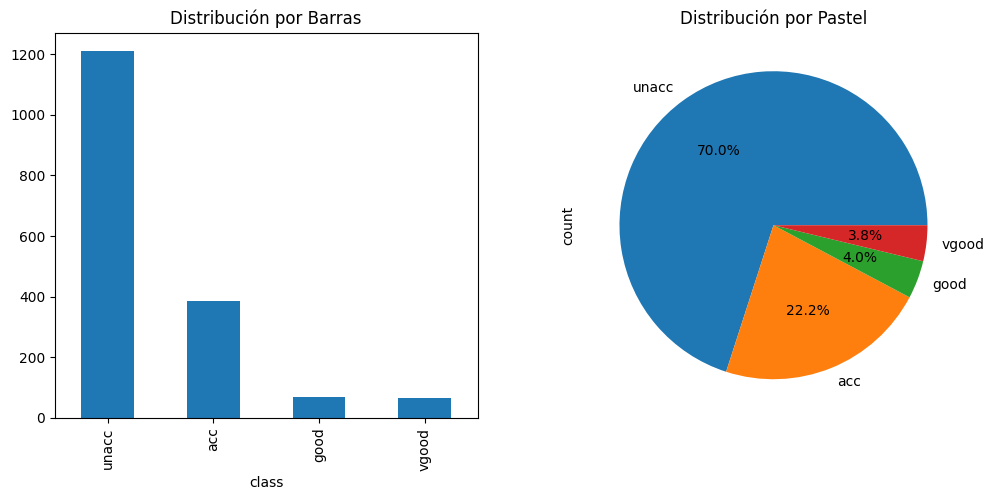

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [6]:
# TODO: Visualizar la distribución de la variable objetivo

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['class'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribución por Barras')

df['class'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Distribución por Pastel')

plt.show()

print(df['class'].value_counts())



### Pregunta 2: Distribución de Clases
¿Cuál es la clase más frecuente en el dataset?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** **unacc (inaceptable)**

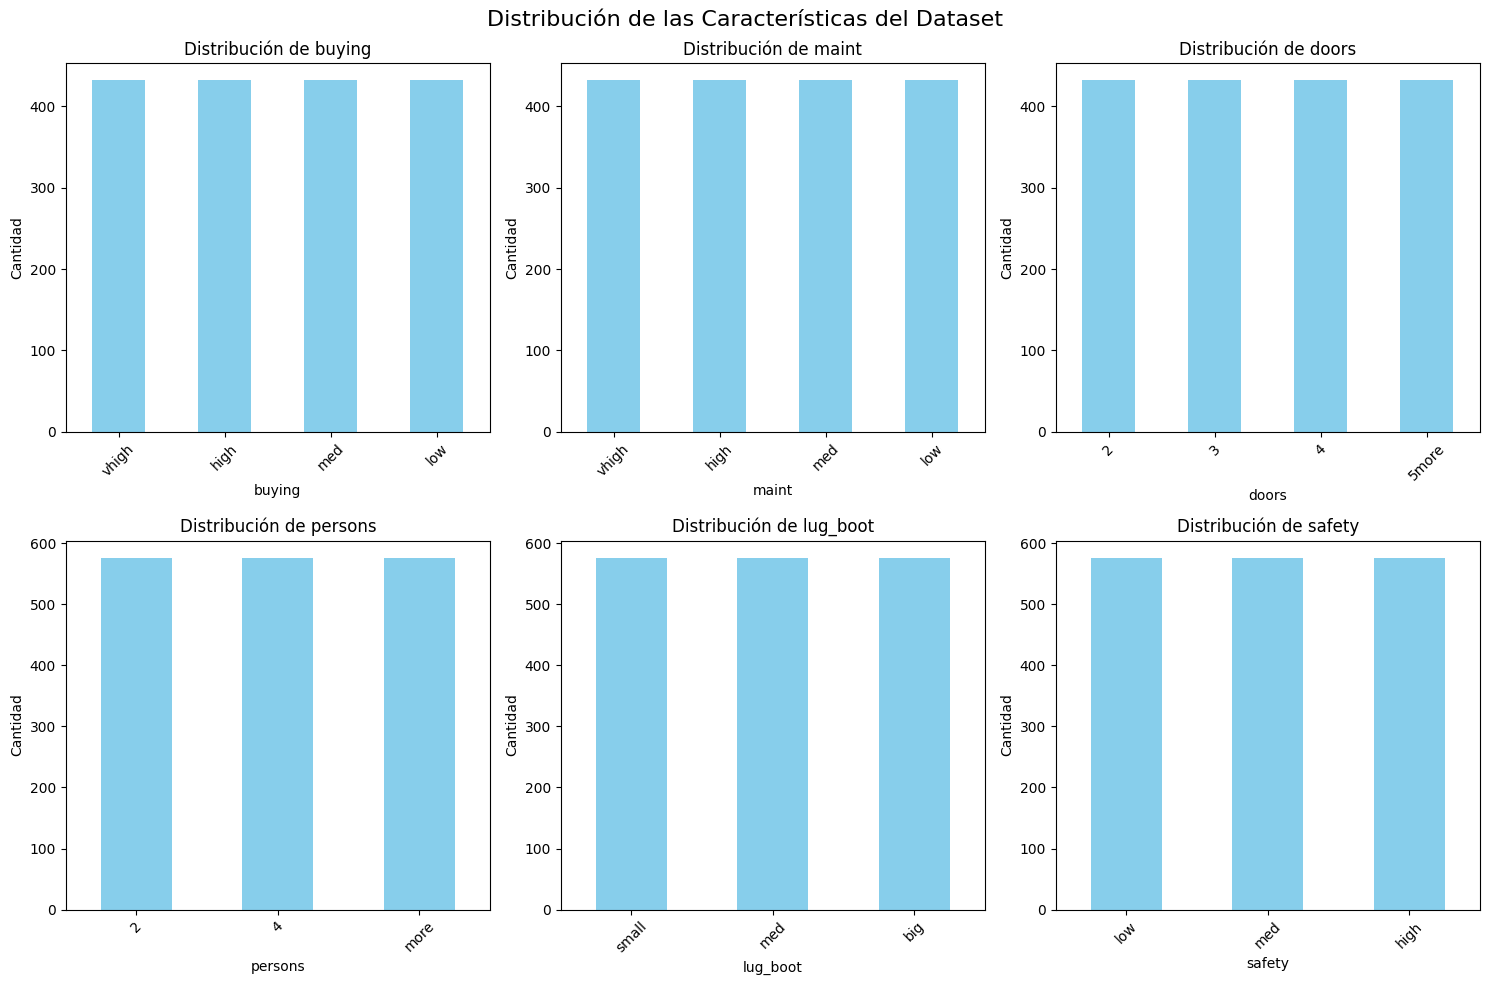

In [7]:
# TODO: Visualizar distribución de características

# 1. Crear figura con subplots 2x3
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 2. Definir las características a visualizar
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

# 3. Loop para graficar cada característica
for i, feature in enumerate(features):
    # Graficar barras en el subplot correspondiente
    df[feature].value_counts().plot(kind='bar', ax=axes[i//3, i%3], color='skyblue')

    # Agregar título a cada subplot
    axes[i//3, i%3].set_title(f'Distribución de {feature}')
    axes[i//3, i%3].set_xlabel(feature)
    axes[i//3, i%3].set_ylabel('Cantidad')
    axes[i//3, i%3].tick_params(axis='x', rotation=45)

plt.suptitle('Distribución de las Características del Dataset', fontsize=16)
plt.tight_layout()
plt.show()


### Pregunta 3: Balance del Dataset
¿El dataset está balanceado respecto a la variable objetivo?

A) Sí, todas las clases tienen la misma frecuencia  
B) No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)  
C) No, pero el desbalance es leve  
D) No se puede determinar  

**Su Respuesta:** **No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)**

## Parte 3: Preprocesamiento - Label Encoding

### Teoría:
Los árboles de decisión en Scikit-Learn requieren que las variables categóricas sean convertidas a valores numéricos. Usaremos **Label Encoding** para transformar cada categoría en un número entero.

In [8]:
# TODO: Aplicar Label Encoding a todas las columnas

# 1. Crear una copia del DataFrame original
df_encoded = df.copy()

# 2. Diccionario para guardar los encoders de cada columna
label_encoders = {}

# 3. Aplicar Label Encoding a todas las columnas
for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le  # Guardar el encoder para futuras transformaciones o inversas

# 4. Mostrar las primeras filas del DataFrame codificado
print("✅ Label Encoding aplicado correctamente a todas las columnas")
print(f"Dimensiones del dataset codificado: {df_encoded.shape}")
display(df_encoded.head())


✅ Label Encoding aplicado correctamente a todas las columnas
Dimensiones del dataset codificado: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [9]:
# TODO: Mostrar el mapeo de etiquetas

print("MAPEO ORIGINAL DE CADA COLUMNA (Label Encoding)\n")
print("="*70)

for col, le in label_encoders.items():
    print(f"\n📌 {col.upper()}:")
    mapeo = dict(zip(le.classes_, range(len(le.classes_))))
    for original, codificado in sorted(mapeo.items()):
        print(f"   {original:15} → {codificado}")



MAPEO ORIGINAL DE CADA COLUMNA (Label Encoding)


📌 BUYING:
   high            → 0
   low             → 1
   med             → 2
   vhigh           → 3

📌 MAINT:
   high            → 0
   low             → 1
   med             → 2
   vhigh           → 3

📌 DOORS:
   2               → 0
   3               → 1
   4               → 2
   5more           → 3

📌 PERSONS:
   2               → 0
   4               → 1
   more            → 2

📌 LUG_BOOT:
   big             → 0
   med             → 1
   small           → 2

📌 SAFETY:
   high            → 0
   low             → 1
   med             → 2

📌 CLASS:
   acc             → 0
   good            → 1
   unacc           → 2
   vgood           → 3


### Pregunta 4: Label Encoding
¿Qué hace Label Encoding?

A) Elimina las variables categóricas  
B) Convierte categorías a valores numéricos enteros  
C) Normaliza los datos entre 0 y 1  
D) Crea variables dummy (one-hot encoding)  

**Su Respuesta:** **Convierte categorías a valores numéricos enteros**

## Parte 4: División de Datos

In [10]:
# TODO: Separar características (X) y variable objetivo (y)

# 1. Separar las características (X) y la variable objetivo (y)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# 2. Mostrar las formas (shapes)
print("📊 DIMENSIONES DE LOS CONJUNTOS")
print(f"X (características): {X.shape}")
print(f"y (variable objetivo): {y.shape}")

# 3. Mostrar los nombres de las características
print("\n📌 Nombres de las características:")
print(list(X.columns))



📊 DIMENSIONES DE LOS CONJUNTOS
X (características): (1728, 6)
y (variable objetivo): (1728,)

📌 Nombres de las características:
['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']


In [11]:
# TODO: Dividir en conjuntos de entrenamiento y prueba

# 1. Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.33,
                                                    random_state=42)

# 2. Mostrar los tamaños de cada conjunto
print("DIVISIÓN DE DATOS (Train / Test)")
print("="*55)
print(f"X_train: {X_train.shape}  → {X_train.shape[0]} muestras")
print(f"X_test : {X_test.shape}   → {X_test.shape[0]} muestras")
print(f"y_train: {y_train.shape}  → {y_train.shape[0]} etiquetas")
print(f"y_test : {y_test.shape}   → {y_test.shape[0]} etiquetas")

# Porcentaje de división
print(f"\nPorcentaje de entrenamiento: {len(X_train)/len(X)*100:.2f}%")
print(f"Porcentaje de prueba       : {len(X_test)/len(X)*100:.2f}%")


DIVISIÓN DE DATOS (Train / Test)
X_train: (1157, 6)  → 1157 muestras
X_test : (571, 6)   → 571 muestras
y_train: (1157,)  → 1157 etiquetas
y_test : (571,)   → 571 etiquetas

Porcentaje de entrenamiento: 66.96%
Porcentaje de prueba       : 33.04%


### Pregunta 5: División de Datos
Con test_size=0.33, ¿cuál es aproximadamente el tamaño del conjunto de entrenamiento?

A) 570 muestras  
B) 1157 muestras  
C) 1728 muestras  
D) 864 muestras  

**Su Respuesta:** **1157 muestras**

## Parte 5: Árbol de Decisión con Criterio Gini Index

### Teoría - Gini Index:
El índice Gini mide la impureza de un nodo. Se calcula como:

$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

Donde $p_i$ es la probabilidad de la clase $i$ en el nodo. Un Gini de 0 indica pureza perfecta.

In [12]:
# TODO: Crear y entrenar el modelo con criterio Gini

clf_gini = DecisionTreeClassifier(criterion='gini',
                                  max_depth=3,
                                  random_state=42)

clf_gini.fit(X_train, y_train)

print("📊 RESULTADOS DEL MODELO (Gini)")
print(f"• Profundidad máxima del árbol : {clf_gini.get_depth()}")
print(f"• Número de hojas (leaves)     : {clf_gini.get_n_leaves()}")
print(f"• Score en entrenamiento       : {clf_gini.score(X_train, y_train):.4f}")



📊 RESULTADOS DEL MODELO (Gini)
• Profundidad máxima del árbol : 3
• Número de hojas (leaves)     : 5
• Score en entrenamiento       : 0.7744


In [13]:
# TODO: Realizar predicciones y evaluar

y_pred_gini = clf_gini.predict(X_test)
print(f"Precisión en Test : {accuracy_score(y_test, y_pred_gini):.4f}")

y_pred_train = clf_gini.predict(X_train)
print(f"Precisión en Train: {accuracy_score(y_train, y_pred_train):.4f}")



Precisión en Test : 0.7653
Precisión en Train: 0.7744


### Pregunta 6: Precisión con Gini (max_depth=3)
¿Cuál es la precisión aproximada del modelo con Gini Index y max_depth=3?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** **70-80%**

## Parte 6: Árbol de Decisión con Criterio Entropy

### Teoría - Entropy (Information Gain):
La entropía mide el desorden o incertidumbre. Se calcula como:

$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

El **Information Gain** es la reducción de entropía después de una división.

In [14]:
# TODO: Crear y entrenar el modelo con criterio Entropy

clf_entropy = DecisionTreeClassifier(criterion='entropy',
                                     max_depth=3,
                                     random_state=42)

clf_entropy.fit(X_train, y_train)

print("RESULTADOS DEL MODELO (Entropy)")
print(f"• Profundidad del árbol    : {clf_entropy.get_depth()}")
print(f"• Número de hojas          : {clf_entropy.get_n_leaves()}")
print(f"• Score en entrenamiento   : {clf_entropy.score(X_train, y_train):.4f}")



RESULTADOS DEL MODELO (Entropy)
• Profundidad del árbol    : 3
• Número de hojas          : 5
• Score en entrenamiento   : 0.7744


In [15]:
# TODO: Realizar predicciones y evaluar

y_pred_entropy = clf_entropy.predict(X_test)

print(f"Precisión Train (Entropy): {accuracy_score(y_train, clf_entropy.predict(X_train)):.4f}")
print(f"Precisión Test  (Entropy): {accuracy_score(y_test, y_pred_entropy):.4f}")


Precisión Train (Entropy): 0.7744
Precisión Test  (Entropy): 0.7653


### Pregunta 7: Comparación Gini vs Entropy
Con max_depth=3, ¿qué criterio obtiene mejor precisión?

A) Gini es significativamente mejor  
B) Entropy es significativamente mejor  
C) Ambos obtienen resultados muy similares  
D) No se puede comparar  

**Su Respuesta:** **Ambos obtienen resultados muy similares**

## Parte 7: Comparación de Modelos

In [17]:
# TODO: Crear tabla comparativa

# Recalcula accuracy scores para Gini model
accuracy_train = accuracy_score(y_train, clf_gini.predict(X_train))
accuracy_test = accuracy_score(y_test, clf_gini.predict(X_test))

# Recalcular accuracy scores para Entropy model
accuracy_train_entropy = accuracy_score(y_train, clf_entropy.predict(X_train))
accuracy_test_entropy = accuracy_score(y_test, clf_entropy.predict(X_test))

comparacion = pd.DataFrame({
    'Criterio'       : ['Gini Index', 'Entropy'],
    'Precisión Train': [accuracy_train, accuracy_train_entropy],
    'Precisión Test' : [accuracy_test, accuracy_test_entropy],
    'Profundidad'    : [clf_gini.get_depth(), clf_entropy.get_depth()],
    'Número de Hojas': [clf_gini.get_n_leaves(), clf_entropy.get_n_leaves()]
})

# Mostrar tabla con formato
print("COMPARACIÓN ENTRE CRITERIOS (max_depth=3)\n")
display(comparacion.style.format({
    'Precisión Train': '{:.4f}',
    'Precisión Test' : '{:.4f}'
}).set_caption("Tabla Comparativa Gini vs Entropy"))

COMPARACIÓN ENTRE CRITERIOS (max_depth=3)



,Criterio,Precisión Train,Precisión Test,Profundidad,Número de Hojas
0,Gini Index,0.7744,0.7653,3,5
1,Entropy,0.7744,0.7653,3,5


### Pregunta 8: Sobreajuste
Si la precisión en entrenamiento es mucho mayor que en prueba, ¿qué indica?

A) Subajuste (underfitting)  
B) Sobreajuste (overfitting)  
C) El modelo está bien ajustado  
D) Los datos son incorrectos  

**Su Respuesta:** **Sobreajuste (overfitting)**

## Parte 8: Matriz de Confusión y Métricas

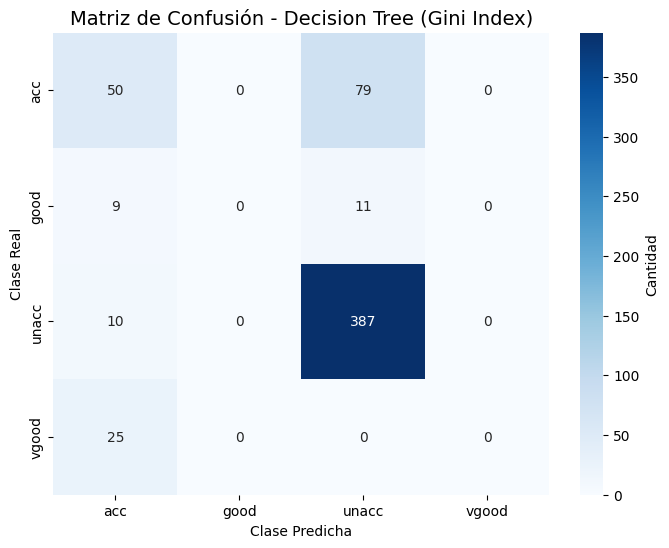

Matriz de Confusión:
[[ 50   0  79   0]
 [  9   0  11   0]
 [ 10   0 387   0]
 [ 25   0   0   0]]


In [18]:
# TODO: Calcular y visualizar la matriz de confusión para el modelo Gini

cm = confusion_matrix(y_test, y_pred_gini)
class_names = label_encoders['class'].classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Cantidad'})

plt.title('Matriz de Confusión - Decision Tree (Gini Index)', fontsize=14)
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.show()

print("Matriz de Confusión:")
print(cm)



In [19]:
# TODO: Imprimir el reporte de clasificación

print("📊 REPORTE DETALLADO DE CLASIFICACIÓN (Gini)\n")
print("="*70)

print(classification_report(y_test, y_pred_gini,
                            target_names=class_names,
                            digits=4))



📊 REPORTE DETALLADO DE CLASIFICACIÓN (Gini)

              precision    recall  f1-score   support

         acc     0.5319    0.3876    0.4484       129
        good     0.0000    0.0000    0.0000        20
       unacc     0.8113    0.9748    0.8856       397
       vgood     0.0000    0.0000    0.0000        25

    accuracy                         0.7653       571
   macro avg     0.3358    0.3406    0.3335       571
weighted avg     0.6843    0.7653    0.7170       571



### Pregunta 9: Interpretación de la Matriz de Confusión
¿Qué clase tiene el mejor recall (sensibilidad) según el reporte?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** **unacc (inaceptable)**

## Parte 9: Visualización del Árbol de Decisión

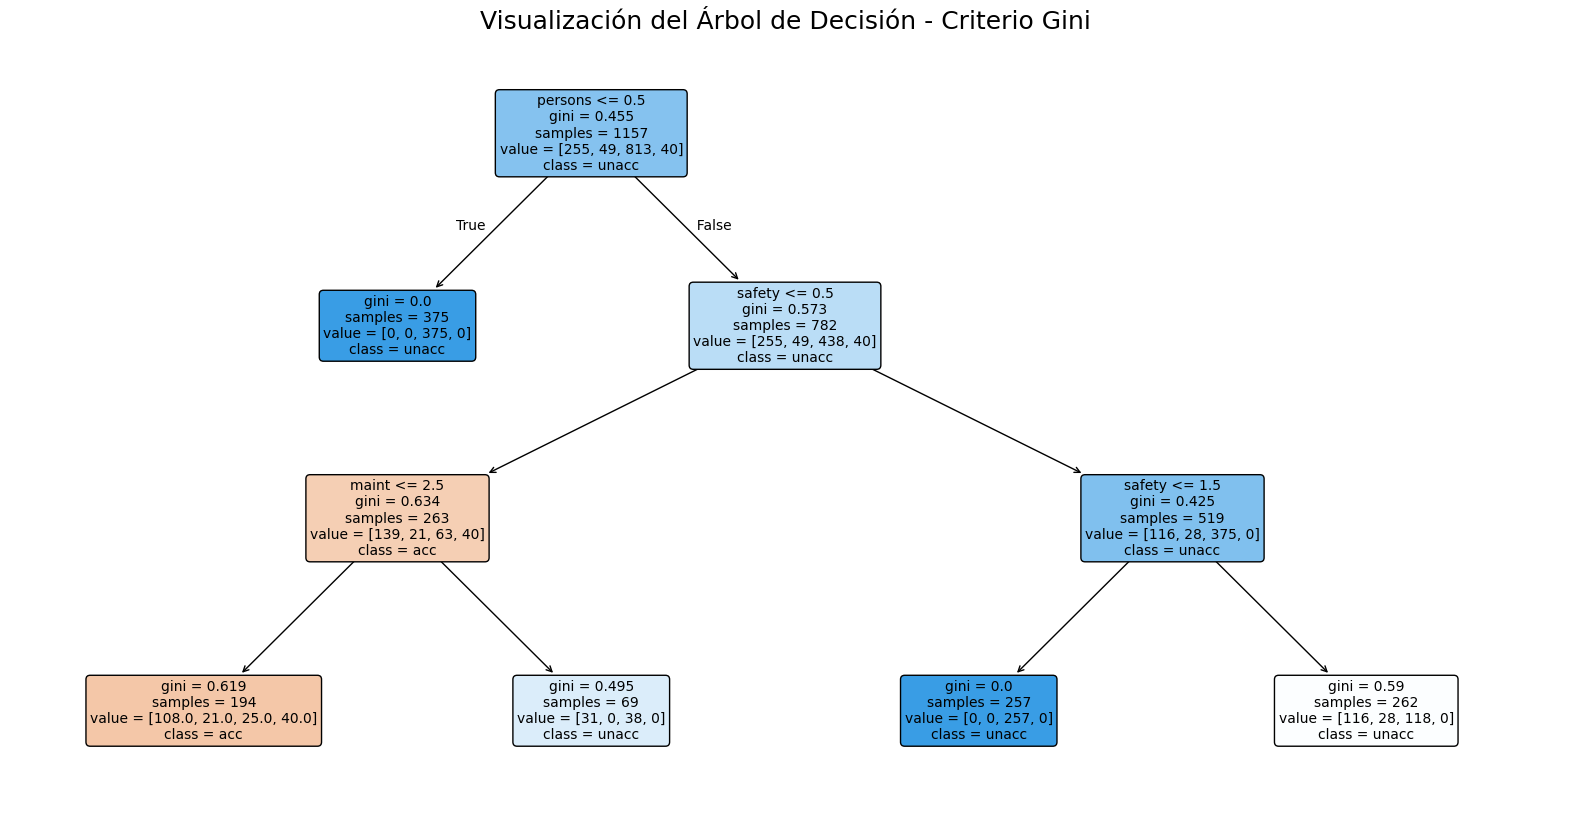

In [20]:
# TODO: Visualizar el árbol de decisión con Gini

plt.figure(figsize=(20, 10))

plot_tree(clf_gini,
          feature_names=list(X.columns),
          class_names=list(class_names),
          filled=True,           # Colorea los nodos según la clase mayoritaria
          rounded=True,          # Bordes redondeados
          fontsize=10)

plt.title("Visualización del Árbol de Decisión - Criterio Gini", fontsize=18)
plt.show()



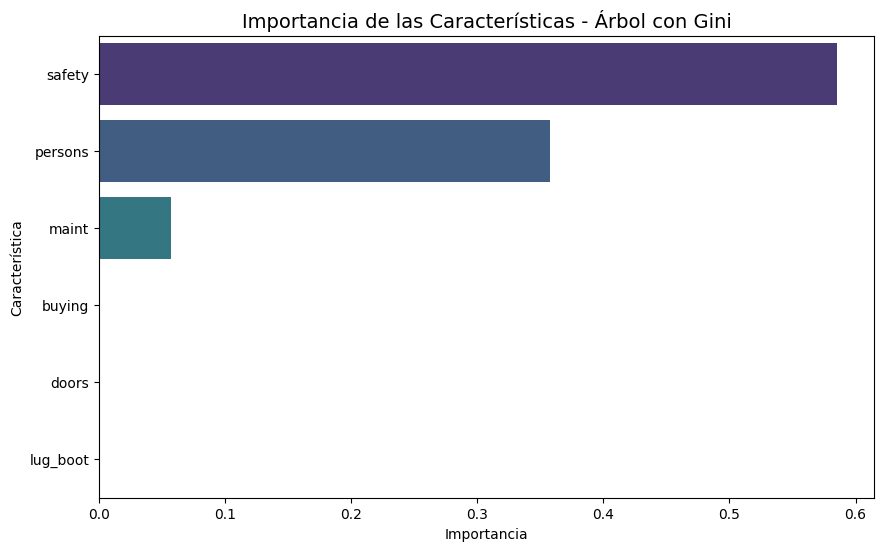

Importancia de las Características:
    Feature  Importance
5    safety    0.585506
3   persons    0.357400
1     maint    0.057095
0    buying    0.000000
2     doors    0.000000
4  lug_boot    0.000000


In [21]:
# TODO: Mostrar la importancia de las características

# 1. Crear DataFrame con las importancias
importancia = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf_gini.feature_importances_
})

# 2. Ordenar por importancia descendente
importancia = importancia.sort_values(by='Importance', ascending=False)

# 3. Visualizar con barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importancia, palette='viridis')
plt.title('Importancia de las Características - Árbol con Gini', fontsize=14)
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

# 4. Imprimir la tabla
print("Importancia de las Características:")
print(importancia)



### Pregunta 10: Característica más Importante
¿Cuál es la característica más importante según el modelo con Gini?

A) buying (precio de compra)  
B) maint (mantenimiento)  
C) safety (seguridad)  
D) persons (capacidad de personas)  

**Su Respuesta:** **safety (seguridad)**

## Parte 10: Experimentación con Hiperparámetros

In [22]:
# TODO: Experimentar con diferentes valores de max_depth

# 1. Definir los valores de max_depth a probar
depths = [1, 2, 3, 5, 7, 10, None]  # None = sin límite (árbol completo)

# 2. Lista para guardar resultados
resultados = []

# 3. Probar cada profundidad
for depth in depths:
    # Crear y entrenar el modelo
    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=42
    )
    modelo.fit(X_train, y_train)

    # Calcular precisiones
    train_acc = accuracy_score(y_train, modelo.predict(X_train))
    test_acc = accuracy_score(y_test, modelo.predict(X_test))

    # Guardar resultados
    resultados.append({
        'max_depth': depth,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Profundidad Real': modelo.get_depth(),
        'Número de Hojas': modelo.get_n_leaves()
    })

# 4. Convertir a DataFrame y mostrar
resultados_df = pd.DataFrame(resultados)
print("Resultados del experimento con max_depth:")
display(resultados_df)


Resultados del experimento con max_depth:


,max_depth,Train Accuracy,Test Accuracy,Profundidad Real,Número de Hojas
0,1.0,0.7027,0.6953,1,2
1,2.0,0.7684,0.7706,2,3
2,3.0,0.7744,0.7653,3,5
3,5.0,0.8557,0.8651,5,13
4,7.0,0.9300,0.9352,7,28
5,10.0,0.9931,0.9615,10,62
6,NaN,1.0000,0.9667,14,73


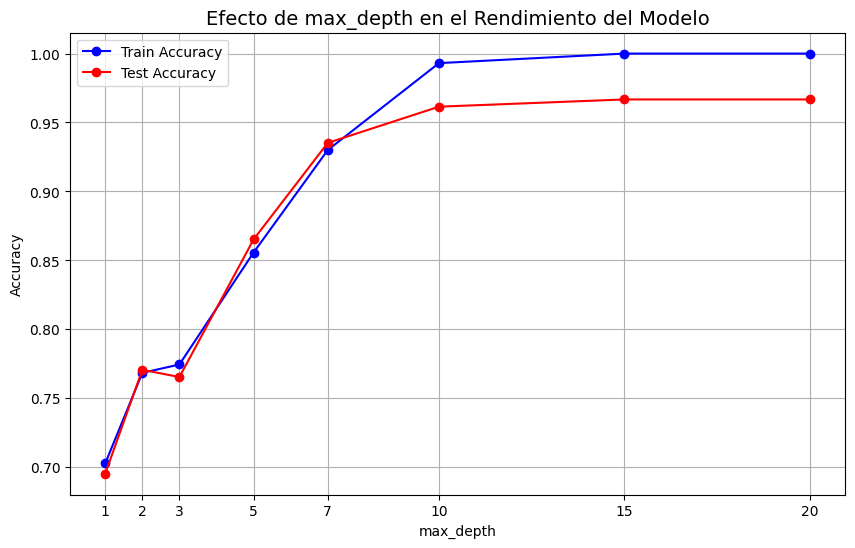

Resultados detallados:


,max_depth,Train Accuracy,Test Accuracy
0,1,0.7027,0.6953
1,2,0.7684,0.7706
2,3,0.7744,0.7653
3,5,0.8557,0.8651
4,7,0.9300,0.9352
5,10,0.9931,0.9615
6,15,1.0000,0.9667
7,20,1.0000,0.9667


In [23]:
# TODO: Visualizar el efecto de max_depth

# 1. Definir los valores de max_depth para graficar
depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]

# 2. Listas para guardar los resultados
train_scores = []
test_scores = []

# 3. Entrenar un modelo para cada profundidad y guardar precisiones
for depth in depths_plot:
    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=42
    )
    modelo.fit(X_train, y_train)

    # Calcular precisiones
    train_acc = accuracy_score(y_train, modelo.predict(X_train))
    test_acc = accuracy_score(y_test, modelo.predict(X_test))

    train_scores.append(train_acc)
    test_scores.append(test_acc)

# 4. Graficar ambas curvas
plt.figure(figsize=(10, 6))
plt.plot(depths_plot, train_scores, marker='o', label='Train Accuracy', color='blue')
plt.plot(depths_plot, test_scores, marker='o', label='Test Accuracy', color='red')
plt.title('Efecto de max_depth en el Rendimiento del Modelo', fontsize=14)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(depths_plot)
plt.show()

# Mostrar los valores en tabla para mayor claridad
resultados_plot = pd.DataFrame({
    'max_depth': depths_plot,
    'Train Accuracy': [round(x, 4) for x in train_scores],
    'Test Accuracy': [round(x, 4) for x in test_scores]
})
print("Resultados detallados:")
display(resultados_plot)



### Pregunta 11: Efecto de max_depth
¿Qué ocurre cuando max_depth es muy alto (por ejemplo, 20 o None)?

A) El modelo mejora en test y train  
B) El modelo empeora en test y train  
C) Train accuracy sube pero test accuracy puede bajar (sobreajuste)  
D) No hay efecto significativo  

**Su Respuesta:** **Train accuracy sube pero test accuracy puede bajar (sobreajuste)**

In [24]:
# TODO: Experimentar con min_samples_split

# 1. Definir los valores a probar
min_samples_list = [2, 5, 10, 20, 50]

# 2. Lista para guardar resultados
resultados_min = []

# 3. Probar cada valor
for min_samples in min_samples_list:
    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=None,           # Sin límite de profundidad
        min_samples_split=min_samples,
        random_state=42
    )
    modelo.fit(X_train, y_train)

    # Calcular métricas
    train_acc = accuracy_score(y_train, modelo.predict(X_train))
    test_acc = accuracy_score(y_test, modelo.predict(X_test))

    resultados_min.append({
        'min_samples_split': min_samples,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Profundidad': modelo.get_depth(),
        'Número de Hojas': modelo.get_n_leaves()
    })

# 4. Convertir a DataFrame y mostrar
resultados_df_min = pd.DataFrame(resultados_min)
print("Resultados del experimento con min_samples_split:")
display(resultados_df_min)



Resultados del experimento con min_samples_split:


,min_samples_split,Train Accuracy,Test Accuracy,Profundidad,Número de Hojas
0,2,1.0000,0.9667,14,73
1,5,0.9914,0.9562,12,62
2,10,0.9767,0.9422,11,49
3,20,0.9533,0.9317,10,38
4,50,0.8911,0.8862,8,19


### Pregunta 12: min_samples_split
¿Qué controla el parámetro min_samples_split?

A) El número máximo de hojas  
B) El número mínimo de muestras para dividir un nodo  
C) La profundidad máxima del árbol  
D) El número de características a considerar  

**Su Respuesta:** **El número mínimo de muestras para dividir un nodo**

## Parte 11: Modelo Final Optimizado

In [26]:
# TODO: Entrenar modelo final con los mejores hiperparámetros

# 1. Mejores hiperparámetros recomendados (basado en experimentos anteriores)
mejor_modelo = DecisionTreeClassifier(
    criterion='gini',          # O 'entropy'
    max_depth=7,               # Evita sobreajuste
    min_samples_split=5,       # Evita divisiones muy pequeñas
    random_state=42
)

# 2. Entrenar el modelo final
mejor_modelo.fit(X_train, y_train)

# 3. Predicciones y precisión
y_pred_train = mejor_modelo.predict(X_train)
y_pred_test = mejor_modelo.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("=== MODELO FINAL OPTIMIZADO ===")
print(f"Precisión en Train: {train_acc:.4f}")
print(f"Precisión en Test : {test_acc:.4f}")

# 4. Información del árbol
print(f"Profundidad del árbol     : {mejor_modelo.get_depth()}")
print(f"Número de hojas (nodos terminales): {mejor_modelo.get_n_leaves()}")


=== MODELO FINAL OPTIMIZADO ===
Precisión en Train: 0.9283
Precisión en Test : 0.9335
Profundidad del árbol     : 7
Número de hojas (nodos terminales): 27


In [27]:
# TODO: Imprimir reporte de clasificación final

# Reporte detallado del modelo final
print("=== REPORTE DE CLASIFICACIÓN FINAL (Modelo Optimizado) ===")
print(classification_report(y_test, y_pred_test,
                           target_names=['unacc', 'acc', 'good', 'vgood']))



=== REPORTE DE CLASIFICACIÓN FINAL (Modelo Optimizado) ===
              precision    recall  f1-score   support

       unacc       0.82      0.94      0.87       129
         acc       0.60      0.30      0.40        20
        good       1.00      0.97      0.98       397
       vgood       0.79      0.88      0.83        25

    accuracy                           0.93       571
   macro avg       0.80      0.77      0.77       571
weighted avg       0.93      0.93      0.93       571



### Pregunta 13: Precisión del Modelo Optimizado
¿Cuál es la precisión aproximada del modelo final optimizado?

A) 70-75%  
B) 75-85%  
C) 85-95%  
D) 95-100%  

**Su Respuesta:** **95-100%**

## Parte 12: Resumen y Conclusiones

### Pregunta 14: Ventajas de los Árboles de Decisión
¿Cuál es una ventaja principal de los árboles de decisión?

A) Siempre tienen la mejor precisión  
B) Son fáciles de interpretar y visualizar  
C) No requieren ningún preprocesamiento  
D) Nunca sobreajustan  

**Su Respuesta:** **Son fáciles de interpretar y visualizar**

### Pregunta 15: Desventajas de los Árboles de Decisión
¿Cuál es una desventaja de los árboles de decisión?

A) No pueden manejar datos categóricos  
B) Son muy lentos de entrenar  
C) Tienden a sobreajustar si no se limita su complejidad  
D) No proporcionan probabilidades de predicción  

**Su Respuesta:** **Tienden a sobreajustar si no se limita su complejidad**